In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import time
from scipy.sparse import coo_matrix, save_npz, load_npz

## Loading Dataset

In [2]:
data_csv = pd.read_csv("data/IMDB_Dataset.csv")
data_csv["sentiment"] = data_csv["sentiment"].replace({"positive":1, "negative":0}) # Classifying +ve/-ve into 0's and 1's
data_csv.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


In [3]:
raw_text = data_csv.iloc[:,0].tolist() # Type: List[str]
len(raw_text), type(raw_text)

(50000, list)

## Standardizing Text :
- Lowercasing: Ate to ate
- Striping Punctuation: Hi! to hi
- Removing Stop Words: A, An, The, It, ...
- Removing \<br /> \<br /> (This is Dataset Specific)

In [4]:
def text_preprocessor(raw_text:list[str]):
    '''
    An Iterator which returns each reviews Standardized Version.
    '''
    # Precompile patterns for efficiency
    punct_pattern = re.compile(r"[^\w\s]")                     # Removes punctuation
    br_pattern    = re.compile(r"<br />\s*<br />")            # Removes consecutive <br /><br />
    article_pattern = re.compile(r"\b(a|the|an|i)\b", re.IGNORECASE)  # Removes Stop-Words
    
    for s in raw_text:
        s = br_pattern.sub(" ", s)             
        s = punct_pattern.sub(" ", s)          
        s = article_pattern.sub(" ", s)        
        s = re.sub(r"\s+", " ", s).strip()    
        yield s.lower().split()

## Example of what text_preprocessor Function is Implementing

In [5]:
sample_text = [
    "<br /><br />This is a sample string, with PUNCTUATION!",
    "The cat jumped over a dog.",
    "An Example is Hard to Think... Do you Know why?"
]

sample_preprocess = iter(text_preprocessor(sample_text))
print(next(sample_preprocess))
print(next(sample_preprocess))

['this', 'is', 'sample', 'string', 'with', 'punctuation']
['cat', 'jumped', 'over', 'dog']


## Creating Vocaubulary {Word: Idx}

In [6]:
def vocab_creator(corpus_iterator = iter(text_preprocessor(raw_text))):
    seen = {"<|UNK|>"} # The <|UNK|> token for Unkown Words.
    vocab = ["<|UNK|>"]
    vocab_size = 100_000 # Number of Unique Words your want in the Vocabulary

    for review in corpus_iterator:
        for token in review:
            if token not in seen:
                seen.add(token)
                vocab.append(token)
                # if len(vocab)%10_000 == 0:
                #     print(len(vocab))
        if len(vocab)>=vocab_size:
            break
    vocabulary = {}
    for i, token in enumerate(vocab):
        vocabulary[token] = i
    return vocabulary

vocabulary = vocab_creator()
len(vocabulary)

100001

## Creating the One-Hot Encoded Bag of Words Matrix

In [7]:
N = len(raw_text) # Number of Documents/Reviews
V = len(vocabulary) # Size of Vocabulary OR Number of Distict Words

rows = []
cols = []
vals = []

corpus_iterator = text_preprocessor(raw_text) # Re-intializing the Iterator/Generator

for i, review in enumerate(corpus_iterator):
    local_count = {}

    for token in review:
        j = vocabulary.get(token, 0) # Gets the Index with the paticular word/token
        local_count[j] = local_count.get(j, 0) + 1 # Local Count of that Word a review/Document

    for j, count in local_count.items():
        rows.append(i) # Document
        cols.append(j) # Word 
        vals.append(count) # Value of (i,j) ie. (Document, Word) AKA count of word_j in document_i
        
# Bag of Words Sparse Matrix, created using Scipy and Quantized it as by default its np.float64
BoW_Matrix = coo_matrix((vals, (rows, cols)), shape=(N, V), dtype=np.float32).tocsr() 

In [8]:
print(f"Sparsity: {100*(1 - BoW_Matrix.mean()):.2f}% | BoW-Matrix Shape: {BoW_Matrix.shape}")

Sparsity: 99.79% | BoW-Matrix Shape: (50000, 100001)


## TF-IDF Encoding

In [9]:
# Normalized-Term-Frequency (TF)
row_sum = np.array(BoW_Matrix.sum(axis=1)).ravel()
row_sum[row_sum == 0] = 1
TF_matrix = BoW_Matrix.multiply(1 / row_sum[:, None]) # Used .multiply so that it scales column-wise and Does not multiply the matrix & vector

# Inverse Doc. Frequency (IDF)
df_vector = np.bincount(BoW_Matrix.indices, minlength=V)
idf_vector = (np.log((1 + N) / (1 + df_vector)) + 1) 

# TF-IDF
TFIDF_matrix = TF_matrix.multiply(idf_vector) # Used .multiply so that it scales column-wise and Does not use matrix multiplication

save_npz("cache/tfidf_matrix.npz", TFIDF_matrix) # Saving the TFIDF Matrix

TFIDF_matrix.shape, idf_vector.shape, TF_matrix.shape

((50000, 100001), (100001,), (50000, 100001))

# FNN Binary Classifier

In [10]:
def sigmoid(z):
    np.clip(z, -500, 500, out=z)
    return 1/(1+(np.exp(-z)))

def relu(z):
    return np.maximum(z,0)

def relu_back(z):
    return (z>0).astype(float)
    
def BCE(g,a, eps=1e-10):
    result = -(a*np.log(g+eps) + (1-a)*np.log(1-g+eps))
    return result.mean()
    
def Accuracy(g,a):
    g_preds = (g>=0.5)
    result = 100*(g_preds==a).mean()
    return result

def forward_prop(A_0):
    Z_1 = W_1@A_0 + b_1
    A_1 = relu(Z_1)

    Z_2 = W_2@A_1 + b_2
    A_2 = relu(Z_2)

    Z_3 = W_3@A_2 + b_3
    A_3 = sigmoid(Z_3)
    return A_3

In [11]:
X_train = load_npz("cache/tfidf_matrix.npz").tocsr().T
y_train = data_csv.iloc[:,1].values.astype(int).reshape(-1,1).T

X_train.shape, y_train.shape

((100001, 50000), (1, 50000))

In [12]:
X_train[:5, :5].toarray()

array([[0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.00543104, 0.01117244, 0.01049759, 0.        , 0.04645963],
       [0.02558552, 0.03759506, 0.02825937, 0.01799422, 0.03126717],
       [0.01609347, 0.        , 0.        , 0.        , 0.        ],
       [0.01972192, 0.        , 0.        , 0.        , 0.        ]])

In [13]:
M, N = X_train.shape
M, N

(100001, 50000)

### Intializing Weights And there 2nd Moments

In [14]:
#Number of Neurons for Each Layer
n1 = 4
n2 = 2 
n3 = 1

#Hidden-Layer-1
W_1 = np.random.randn(n1,M)
b_1 = np.zeros((n1,1))
v_w1 = np.zeros_like(W_1)
v_b1 = b_1.copy()

#Hidden-Layer-2
W_2 = np.random.randn(n2,n1)
b_2 = np.zeros((n2,1))
v_w2 = np.zeros_like(W_2)
v_b2 = b_2.copy() 

#Output-Layer
W_3 = np.random.randn(n3,n2)
b_3 = np.zeros((n3,1))
v_w3 = np.zeros_like(W_3)
v_b3 = b_3.copy()

## Training Loop

In [15]:
# Hyperparameters
alpha = 0.1
beta = 0.9
epochs = 5
batch_size = 128 
eps = 1e-10

# Saving History of Each Metric
loss_hist = []
acc_hist = []

start_time = time.time()
for epoch in range(epochs):
    shuffled_ids = np.random.permutation(N)
    X_shuffle = X_train[:,shuffled_ids]
    y_shuffle = y_train[:,shuffled_ids]
    
    for idx in range(0,N, batch_size):
        end_idx = min(idx+batch_size, N)
        A_0 = X_shuffle[:, idx:end_idx]
        y_batch = y_shuffle[:, idx:end_idx]

        #===== Forward-Prop =====
        Z_1 = W_1@A_0 + b_1
        A_1 = relu(Z_1)

        Z_2 = W_2@A_1 + b_2
        A_2 = relu(Z_2)

        Z_3 = W_3@A_2 + b_3
        A_3 = sigmoid(Z_3)

        #===== Back-Prop =====
        del_3 = A_3 - y_batch
        dW3 = del_3 @ A_2.T/batch_size
        db3 = np.sum(del_3, axis=1, keepdims=True)/batch_size

        del_2 = (W_3.T @ del_3)*relu_back(Z_2)
        dW2 = del_2 @ A_1.T/batch_size
        db2 = np.sum(del_2, axis=1, keepdims=True)/batch_size

        del_1 = (W_2.T @ del_2)*relu_back(Z_1)
        dW1 = del_1 @ A_0.T/batch_size
        db1 = np.sum(del_1, axis=1, keepdims=True)/batch_size

        #==== Updating Weights Through RMSProp ====
        v_w3 = beta*v_w3 + (1-beta)*(dW3**2)
        W_3 = W_3 - alpha*(dW3/np.sqrt(v_w3+eps))

        v_b3 = beta*v_b3 + (1-beta)*(db3**2)
        b_3 = b_3 - alpha*(db3/np.sqrt(v_b3+eps))

        
        v_w2 = beta*v_w2 + (1-beta)*(dW2**2)
        W_2 = W_2 - alpha*(dW2/np.sqrt(v_w2+eps))

        v_b2 = beta*v_b2 + (1-beta)*(db2**2)
        b_2 = b_2 - alpha*(db2/np.sqrt(v_b2+eps))

        
        v_w1 = beta*v_w1 + (1-beta)*(dW1**2)
        W_1 = W_1 - alpha*(dW1/np.sqrt(v_w1+eps))

        v_b1 = beta*v_b1 + (1-beta)*(db1**2)
        b_1 = b_1 - alpha*(db1/np.sqrt(v_b1+eps))
        
    # Computing Each Metric
    y_hat = forward_prop(X_train)
    loss = BCE(y_hat, y_train)
    acc = Accuracy(y_hat, y_train)

    loss_hist.append(loss)
    acc_hist.append(acc)
    
    print(f"Epoch: {epoch:2d} | Loss: {loss_hist[-1]:.4f} | Accuracy: {acc_hist[-1]:.2f}%")

end_time = time.time() - start_time

print(f"\nFinal Loss: {loss_hist[-1]:.4f}")
print(f"Accuracy: {acc_hist[-1]:.2f}%")
print(f"Time Taken: {end_time:.3f} seconds")

Epoch:  0 | Loss: 0.1565 | Accuracy: 94.18%
Epoch:  1 | Loss: 0.1001 | Accuracy: 96.49%
Epoch:  2 | Loss: 0.0849 | Accuracy: 97.05%
Epoch:  3 | Loss: 0.0598 | Accuracy: 97.92%
Epoch:  4 | Loss: 0.0557 | Accuracy: 98.20%

Final Loss: 0.0557
Accuracy: 98.20%
Time Taken: 5.283 seconds


## Plotting the Metric Curves Vs Iterations

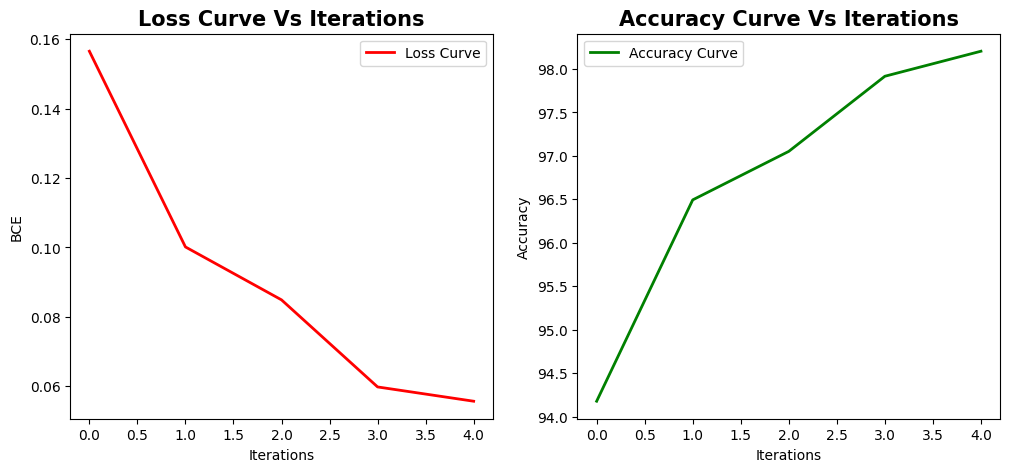

In [16]:
figure = plt.figure(figsize=(12,5))
ax1 = plt.subplot(1,2,1)
ax1.set_title("Loss Curve Vs Iterations", fontweight="bold", fontsize=15)
ax1.set_ylabel("BCE")
ax1.set_xlabel("Iterations")
ax1.plot(np.arange(len(loss_hist)), loss_hist, c="r", label="Loss Curve", lw=2)
ax1.legend()

ax2 = plt.subplot(1,2,2)
ax2.set_title("Accuracy Curve Vs Iterations", fontweight="bold", fontsize=15)
ax2.set_ylabel("Accuracy")
ax2.set_xlabel("Iterations")
ax2.plot(np.arange(len(acc_hist)), acc_hist, c="g", label="Accuracy Curve", lw=2)
ax2.legend()

plt.show()

## Text Vectorizer For Custom Text-Data

In [17]:
def text_vectorizer(text, vocab_dict=vocabulary, IDF_vector=idf_vector, vocab_size=V):
    if type(text)==str:
        text = [""+text]
    
    docs = list(text_preprocessor(text))
    output = []

    for review in docs:
        vec = np.zeros(vocab_size, dtype=np.float32)

        for token in review:
            vec[vocab_dict.get(token, 0)] += 1

        s = vec.sum()
        if s != 0:
            vec = vec / s

        vec = vec * IDF_vector.ravel()
        output.append(vec)

    return np.array(output).T

### Testing On Custom Data Created Using a LLM.

In [18]:
custom_reviews = [
    "I expected a generic action movie, but it turned out to be surprisingly thoughtful. "
    "The pacing in the first half was uneven and a few scenes dragged, yet the final act "
    "was powerful enough to completely win me over. Strong performances and a memorable ending.",

    "The trailer looked promising, which makes the final result even more disappointing. "
    "Despite a talented cast, the dialogue felt artificial, the emotional scenes never landed, "
    "and by the end I was checking how much time was left.",

    "This is not a flawless film, but it is an easy one to admire. "
    "Some side characters are underdeveloped, however the lead performance carries the story "
    "with real charm and sincerity. I left the movie satisfied.",

    "There are moments where the cinematography almost convinces you something meaningful is happening, "
    "but underneath the polished visuals there is very little substance. "
    "The story repeats itself and becomes exhausting rather than engaging.",

    "At first I thought the slow pace would ruin the experience, yet it gradually built tension "
    "in a very smart way. By the final scene I realized how carefully everything had been set up. "
    "Definitely worth watching.",

    "I wanted to like this more than I actually did. "
    "The concept is interesting and a few jokes work, but the screenplay feels messy, "
    "the characters make irrational choices, and the ending is strangely empty.",

    "What impressed me most was how emotionally grounded the movie felt. "
    "Even when the plot became dramatic, it never turned ridiculous. "
    "Beautiful music, strong writing, and excellent chemistry between the leads.",

    "Technically the movie is competent, but competence alone is not enough. "
    "I never cared about anyone on screen, the tension was predictable, "
    "and the so-called twist could be seen coming from miles away.",

    "It starts like a standard comedy, then unexpectedly becomes a touching story about family and regret. "
    "Not every joke lands, yet the warmth and honesty of the second half make it genuinely rewarding.",

    "I can appreciate what the director was attempting, but intention does not equal execution. "
    "Scenes go on forever, the editing is awkward, and several emotional beats feel completely unearned. "
    "A frustrating watch."
]

# Positive = 1, Negative = 0
y_true = np.array([1, 0, 1, 0, 1, 0, 1, 0, 1, 0])

x_vec = text_vectorizer(custom_reviews)
y_preds = forward_prop(x_vec)[0]

# Sentiment Analysis Predictor 
print("Predicted Sentiment of Each Review:")
for preds in y_preds:
    if preds>=0.5:
        print("Positive", end=" ")
    else: 
        print("Negative", end=" ")

Predicted Sentiment of Each Review:
Positive Negative Positive Negative Positive Negative Positive Negative Positive Positive 

In [19]:
test_acc = Accuracy(y_preds,y_true)
print(f"Test Accuracy: {test_acc:.2f}%")

Test Accuracy: 90.00%
